--- 1. Building Discretized Hamiltonian ---
Grid: 5000 points from x = -7.0 to +7.0
Potential: Confining Well V(x) = 1.0*sinh(x)^2 + 10.0*sech(x)^2 - 10.0
... H matrix built.
--- 2. Diagonalizing 5000x5000 H Matrix ---
... Diagonalization complete in 17.54 s
--- 3. Building X and P Matrices in Energy Basis ---
Is X (Energy Basis) Hermitian? True
... Building P matrix using analytical relation P_mn = (m/ih)(En-Em)X_mn
Is P (Energy Basis) Hermitian? True
... X_eb and P_eb built.
--- 4. Calculating C_xp OTOC ---
Partition function Z = 5.6646
Calculating OTOC for 100 states, beta = 0.5...
... OTOC calculation complete in 0.24 s

--- 5. Plotting Results ---


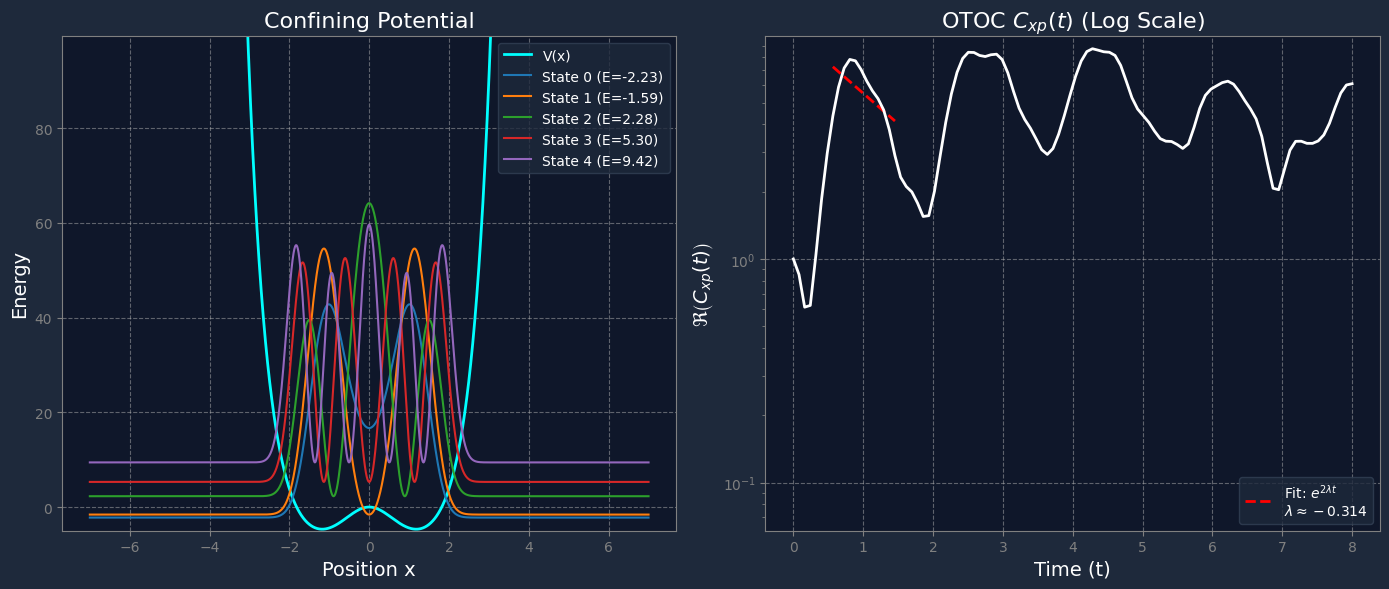

In [4]:
import numpy as np
import scipy.linalg as linalg
import matplotlib.pyplot as plt
import time
import warnings

# --- 0. Setup and Parameters ---

# Suppress warnings
warnings.filterwarnings('ignore', category=RuntimeWarning) # Ignore NaN warnings

# Grid parameters
N_points = 5000      
L = 7.0          
x_vec = np.linspace(-L, L, N_points)
dx = x_vec[1] - x_vec[0]

# Physics parameters
hbar = 1.0
m = 0.5  # Set 2m=1, as in the Hashimoto paper
hbar_sq_over_2m = hbar**2 / (2.0 * m)


a1 = 1.0   # V1 > 0 creates the confining walls
a2 = 10.0  # V2 > 0 sets the depth of the central well

def sech(x):
    return 1 / np.cosh(x)



def get_potential(x, a1, a2):
    """
    Returns the stable, confining volcano potential (Hermitian)
    V(x) = a1 * sinh(x)^2 + a2 * sech(x)^2
    """
    sinh_term = np.sinh(x)**2
    sech_term = sech(x)**2
    
    V_raw = a1 * sinh_term + a2 * sech_term
    
    # Shift potential so the minimum (at x=0) is at 0
    V_min = a2 # V(0) = a1*0 + a2*1 = a2
    return V_raw - V_min

print(f"--- 1. Building Discretized Hamiltonian ---")
print(f"Grid: {N_points} points from x = -{L} to +{L}")
print(f"Potential: Confining Well V(x) = {a1}*sinh(x)^2 + {a2}*sech(x)^2 - {a2}")

# Get potential V(x) at each grid point
V_x = get_potential(x_vec, a1, a2)
V_mat = np.diag(V_x)

# Build Kinetic Matrix T = -hbar^2/(2m) * d^2/dx^2
T_mat = np.zeros((N_points, N_points))
diag_val = 2.0 * hbar_sq_over_2m / (dx**2)
off_diag_val = -1.0 * hbar_sq_over_2m / (dx**2)

np.fill_diagonal(T_mat, diag_val)
np.fill_diagonal(T_mat[1:], off_diag_val)
np.fill_diagonal(T_mat[:, 1:], off_diag_val)

# Full Hamiltonian
H_mat = T_mat + V_mat

print("... H matrix built.")


print(f"--- 2. Diagonalizing {N_points}x{N_points} H Matrix ---")
start_time = time.time()


eigenvalues, eigenvectors = linalg.eigh(H_mat)

end_time = time.time()
print(f"... Diagonalization complete in {end_time - start_time:.2f} s")

basis_size = N_points
H_eb = np.diag(eigenvalues)


print("--- 3. Building X and P Matrices in Energy Basis ---")

X_pos_basis = np.diag(x_vec)
C = eigenvectors
C_dagger = C.T.conj()

X_eb = C_dagger @ X_pos_basis @ C
print(f"Is X (Energy Basis) Hermitian? {np.allclose(X_eb, X_eb.T.conj())}")

print("... Building P matrix using analytical relation P_mn = (m/ih)(En-Em)X_mn")
E_m_matrix = np.tile(eigenvalues, (N_points, 1)).T
E_n_matrix = np.tile(eigenvalues, (N_points, 1))
E_diff_matrix = E_n_matrix - E_m_matrix

P_eb = (m / (1j * hbar)) * E_diff_matrix * X_eb

print(f"Is P (Energy Basis) Hermitian? {np.allclose(P_eb, P_eb.T.conj())}")
print("... X_eb and P_eb built.")

print("--- 4. Calculating C_xp OTOC ---")

beta = 0.5  # Inverse temperature
t_values = np.linspace(0, 8.0, 100)
otoc_values = []

N_thermal = 100 
E_thermal = eigenvalues[:N_thermal]


rho_beta = np.diag(np.exp(-beta * E_thermal))
Z = np.trace(rho_beta)
rho_beta_norm = rho_beta / Z


if Z == 0 or not np.isfinite(Z):
    print("ERROR: Partition function Z is zero or invalid. Stopping.")
else:
    print(f"Partition function Z = {Z:.4f}")
    X = X_eb[:N_thermal, :N_thermal]
    P = P_eb[:N_thermal, :N_thermal]
    H = H_eb[:N_thermal, :N_thermal]

    print(f"Calculating OTOC for {N_thermal} states, beta = {beta}...")
    start_time = time.time()

    for t in t_values:
        U_t = linalg.expm(-1j * H * t / hbar)
        U_dag_t = linalg.expm(1j * H * t / hbar)
        X_t = U_dag_t @ X @ U_t
        Comm_t = (X_t @ P) - (P @ X_t)
        OTOC_op = - (Comm_t @ Comm_t)
        otoc_value = np.trace(rho_beta_norm @ OTOC_op)
        otoc_values.append(np.real(otoc_value))

    end_time = time.time()
    print(f"... OTOC calculation complete in {end_time - start_time:.2f} s")


print("\n--- 5. Plotting Results ---")

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)

ax1.plot(x_vec, V_x, color='cyan', lw=2, label="V(x)")
ax1.set_title(f"Confining Potential", fontsize=16)
ax1.set_xlabel("Position x", fontsize=14)
ax1.set_ylabel("Energy", fontsize=14)

plot_states = 5

V_max_plot = np.max(V_x[np.abs(x_vec) < 3]) # Max height of central barrier
psi_max = np.max(np.abs(eigenvectors[:, 0])**2)
plot_scale = (V_max_plot * 0.5) / psi_max

for i in range(plot_states):
    eigenstate = eigenvectors[:, i]
    energy = eigenvalues[i]
    # Plot |psi|^2, scaled for visibility
    psi_sq_scaled = plot_scale * np.abs(eigenstate)**2 + energy
    ax1.plot(x_vec, psi_sq_scaled, label=f"State {i} (E={energy:.2f})")

ax1.set_ylim(-5, eigenvalues[plot_states-1] + V_max_plot) # Zoom in
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: The OTOC
ax2 = plt.subplot(1, 2, 2)

otoc_plot_values = np.array(otoc_values)
finite_mask = np.isfinite(otoc_plot_values)
if np.sum(finite_mask) == 0 or len(otoc_plot_values) == 0:
    print("ERROR: No valid OTOC values to plot.")
    t_plot = t_values
    otoc_plot_values = np.ones_like(t_values) * 1e-10 # Fallback
else:
    t_plot = t_values[finite_mask]
    otoc_plot_values = otoc_plot_values[finite_mask]

small_positive = 1e-10
non_positive_mask = (otoc_plot_values <= 0)
otoc_plot_values[non_positive_mask] = small_positive

plot_label = "Fit: N/A"
try:
    fit_start_t, fit_end_t = 0.5, 1.5
    fit_mask = (t_plot >= fit_start_t) & (t_plot <= fit_end_t)
    
    t_fit = t_plot[fit_mask]
    C_fit_log = np.log(otoc_plot_values[fit_mask])

    if len(t_fit) > 2:
        m, c = np.polyfit(t_fit, C_fit_log, 1)
        if np.isfinite(m):
            lambda_L = m / 2.0
            fit_line = np.exp(m * t_fit + c)
           
            ax2.plot(t_fit, fit_line, 'r--', lw=2, label=rf"Fit: $e^{{2\lambda t}}$" + "\n" + rf"$\lambda \approx {lambda_L:.3f}$")
           
        else:
            ax2.plot([], [], 'r--', lw=2, label="Fit: N/A (Fit failed)")
    else:
        ax2.plot([], [], 'r--', lw=2, label="Fit: N/M (Not enough data)")
except Exception as e:
    print(f"Warning: Could not perform exponential fit. Error: {e}")
    ax2.plot([], [], 'r--', lw=2, label=f"Fit: N/A (Error: {e})")

ax2.semilogy(t_plot, otoc_plot_values, 'w-', lw=2)
ax2.set_title(r"OTOC $C_{xp}(t)$ (Log Scale)", fontsize=16)
ax2.set_xlabel("Time (t)", fontsize=14)
ax2.set_ylabel(r"$\Re \left( C_{xp}(t) \right)$", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)

legend = ax2.legend(loc='lower right')

bottom_lim = np.min(otoc_plot_values[otoc_plot_values > 0]) * 0.1
if bottom_lim <= 0 or not np.isfinite(bottom_lim):
    bottom_lim = small_positive
ax2.set_ylim(bottom=bottom_lim) 

# Dark mode styling
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f172a')
    ax.tick_params(colors='gray', which='both')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
    if ax.get_legend():
        legend_frame = ax.get_legend().get_frame()
        legend_frame.set_facecolor('#1e293b')
        legend_frame.set_edgecolor('#334155')
        for text in ax.get_legend().get_texts():
            text.set_color('white')

plt.gcf().set_facecolor('#1e293b')
plt.tight_layout()
plt.show()